# Embedding Regression & Visualization on DJA

This notebook extracts CLS embeddings from a trained MASpecFormer on DJA spectra, runs regression benchmarks, and visualizes embedding geometry.

In [34]:
import os
import sys
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    import umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False
    umap = None


In [ ]:
# Config
SPEC_CKPT = "/home/yacheng/ssl_outthere/encoder_spectrum/ma_specformer/outputs/dja_prism_f100lp_20260226_235137/last.ckpt"
H5_PATH = "/home/yacheng/ssl_outthere/images/DJA/dja_spectra_low.h5"

MIN_SN50 = 10.0
MAX_LENGTH = 100
BATCH_SIZE = 512
NUM_WORKERS = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Optional image encoder checkpoint (stub section below)
IMG_CKPT = "/home/yacheng/ssl_outthere/encoder_image/astrodino/outputs/does_not_exist.ckpt"

# Ensure project root is importable
PROJECT_ROOT = Path("/home/yacheng/ssl_outthere")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"DEVICE={DEVICE}")
print(f"HAS_UMAP={HAS_UMAP}")


DEVICE=cuda
HAS_UMAP=True


In [56]:
def normalize_flux(flux: torch.Tensor, valid_mask: torch.Tensor, min_std: float = 0.1):
    # Per-sample normalization over valid positions only (matches MASpecFormer training).
    valid_flux = flux.clone()
    valid_flux[~valid_mask] = 0.0

    valid_count = valid_mask.sum(dim=1, keepdim=True).float().clamp(min=1)
    mean = valid_flux.sum(dim=1, keepdim=True) / valid_count

    sq_diff = ((flux - mean) ** 2) * valid_mask.float()
    var = sq_diff.sum(dim=1, keepdim=True) / valid_count
    std = var.sqrt().clamp(min=min_std)

    flux_norm = (flux - mean) / std
    flux_norm = flux_norm * valid_mask.float()
    return flux_norm, mean, std


def extract_spec_embeddings(model, dataloader, device: str = "cpu", min_std: float = 0.1):
    # Extract CLS embeddings + token-mean pooled embeddings in deterministic dataset order.
    model.eval()
    model.to(device)

    all_cls = []
    all_tok_pool = []
    all_mean = []
    all_std = []

    with torch.no_grad():
        for batch in dataloader:
            flux = batch["flux"].to(device).float()
            wave = batch["wavelength"].to(device).float()
            valid_mask = batch["valid_mask"].to(device).bool()

            flux_norm, mean, std = normalize_flux(flux, valid_mask, min_std=min_std)
            stats = torch.cat([mean, std], dim=-1)

            x = model.encode(
                flux=flux_norm,
                wavelengths=wave,
                valid_mask=valid_mask,
                stats=stats,
                return_cls_only=False,
            )  # (B, T+1, D)

            cls_emb = x[:, 0, :]           # (B, D)
            tok_emb = x[:, 1:, :]          # (B, T, D)

            # Mean pool token embeddings over valid (non-padding, non-invalid) positions.
            mask = valid_mask.unsqueeze(-1).float()     # (B, T, 1)
            denom = mask.sum(dim=1).clamp(min=1.0)      # (B, 1)
            tok_pool = (tok_emb * mask).sum(dim=1) / denom

            all_cls.append(cls_emb.cpu().numpy())
            all_tok_pool.append(tok_pool.cpu().numpy())
            all_mean.append(mean.squeeze(-1).cpu().numpy())
            all_std.append(std.squeeze(-1).cpu().numpy())

    cls_emb = np.concatenate(all_cls, axis=0)
    tok_pool_emb = np.concatenate(all_tok_pool, axis=0)
    mean_flux = np.concatenate(all_mean, axis=0)
    std_flux = np.concatenate(all_std, axis=0)
    return cls_emb, tok_pool_emb, mean_flux, std_flux


In [57]:
from encoder_spectrum.ma_specformer.model.ma_specformer import MASpecFormer
from encoder_spectrum.ma_specformer.data.dataset import DJASpectrumDataset
from encoder_spectrum.ma_specformer.data.datamodule import DJASpectrumDataModule

assert Path(SPEC_CKPT).exists(), f"Spec checkpoint not found: {SPEC_CKPT}"
assert Path(H5_PATH).exists(), f"HDF5 not found: {H5_PATH}"

# 1) Load model
spec_model = MASpecFormer.load_from_checkpoint(SPEC_CKPT, map_location=DEVICE)

# 2) Build full dataset with same filters as training config
dataset = DJASpectrumDataset(
    h5_path=H5_PATH,
    min_sn50=MIN_SN50,
    min_length=0,
    max_length=MAX_LENGTH,
)
valid_indices = dataset.valid_indices  # numpy array

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,  # keep order aligned with valid_indices
    num_workers=NUM_WORKERS,
    collate_fn=DJASpectrumDataModule._pad_collate,
)

# 3) Extract embeddings + per-spectrum mean/std (normalized with valid_mask)
cls_emb, tok_pool_emb, flux_mean, flux_std = extract_spec_embeddings(
    spec_model,
    loader,
    device=DEVICE,
    min_std=spec_model.hparams.min_std,
)

# 4) Load metadata by fancy-indexing HDF5 with dataset.valid_indices
with h5py.File(H5_PATH, "r") as f:
    z_best = f["z_best"][valid_indices]
    phot = f["phot_f150w_tot_1"][valid_indices]
    sn50 = f["sn50"][valid_indices]
    srcid = f["srcid"][valid_indices]

# 5) Apply finite mask to ALL arrays simultaneously
finite_mask = (
    np.isfinite(z_best)
    & np.isfinite(phot)
    & np.isfinite(sn50)
    & np.isfinite(flux_mean)
    & np.isfinite(flux_std)
    & np.all(np.isfinite(cls_emb), axis=1)
    & np.all(np.isfinite(tok_pool_emb), axis=1)
)

cls_emb = cls_emb[finite_mask]
tok_pool_emb = tok_pool_emb[finite_mask]
z_best = z_best[finite_mask]
phot = phot[finite_mask]
sn50 = sn50[finite_mask]
flux_mean = flux_mean[finite_mask]
flux_std = flux_std[finite_mask]
srcid = srcid[finite_mask]

print(f"N after filters = {len(cls_emb):,}, embedding_dim = {cls_emb.shape[1]}")
print(f"z_best: [{np.nanmin(z_best):.4f}, {np.nanmax(z_best):.4f}]")
print(f"phot_f150w_tot_1: [{np.nanmin(phot):.4e}, {np.nanmax(phot):.4e}]")
print(f"sn50: [{np.nanmin(sn50):.4f}, {np.nanmax(sn50):.4f}]")


min_length=0: 19513/19513 samples with length >= 0
max_length=100: 19513/19513 samples with length <= 100
sn50 filtering: 3480/19513 samples with sn50 >= 10.0


/home/yacheng/ssl_outthere/.venv/lib64/python3.9/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


N after filters = 2,625, embedding_dim = 128
z_best: [-1.0000, 7.0370]
phot_f150w_tot_1: [-9.9000e+01, 6.9605e+02]
sn50: [10.0010, 636.4234]


## 1. Regression

In [58]:
def run_regression(X, y, label, alpha=1.0, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha, random_state=random_state)),
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    resid = y_test - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].scatter(y_test, y_pred, s=8, alpha=0.35)
    lims = [
        min(float(np.min(y_test)), float(np.min(y_pred))),
        max(float(np.max(y_test)), float(np.max(y_pred))),
    ]
    axes[0].plot(lims, lims, "r--", lw=1)
    axes[0].set_xlabel(f"True {label}")
    axes[0].set_ylabel(f"Pred {label}")
    axes[0].set_title(f"{label}: Pred vs True\nR²={r2:.4f}, MAE={mae:.4g}")

    axes[1].hist(resid, bins=50, alpha=0.8)
    axes[1].set_xlabel("Residual (true - pred)")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"{label}: Residuals")

    plt.tight_layout()
    plt.show()

    return {
        "label": label,
        "r2": float(r2),
        "mae": float(mae),
    }


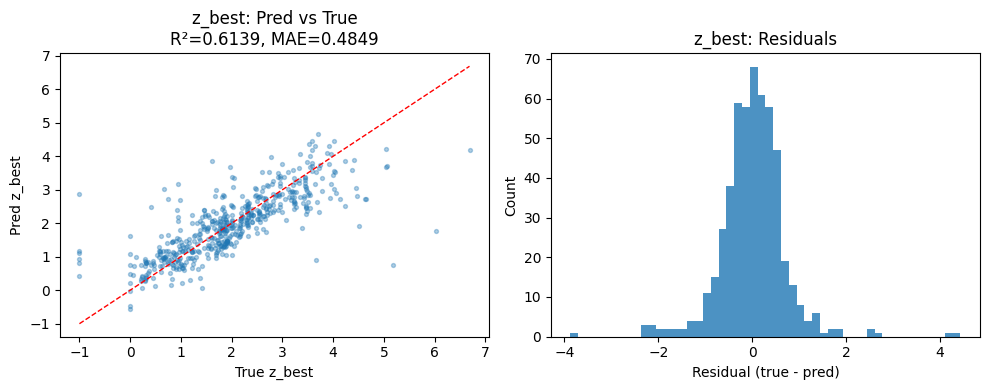

In [59]:
res_z = run_regression(cls_emb, z_best, label="z_best")

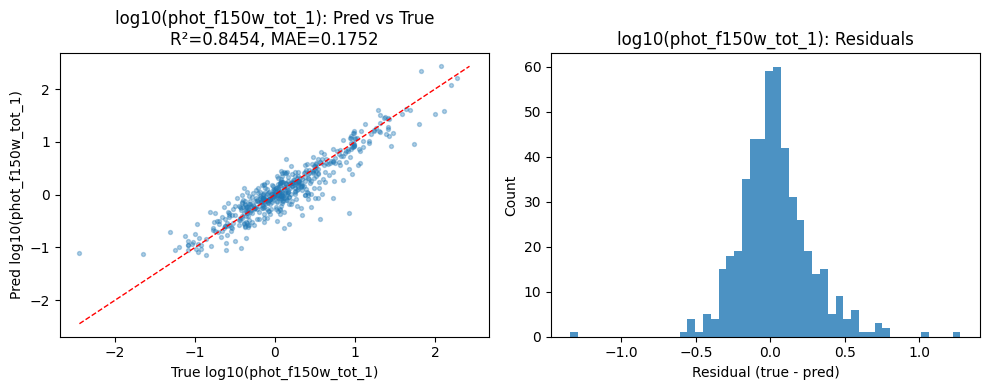

In [60]:
# phot on log10 scale (positive photometry only)
mask_phot_pos = phot > 0
res_phot = run_regression(
    cls_emb[mask_phot_pos],
    np.log10(phot[mask_phot_pos]),
    label="log10(phot_f150w_tot_1)",
)


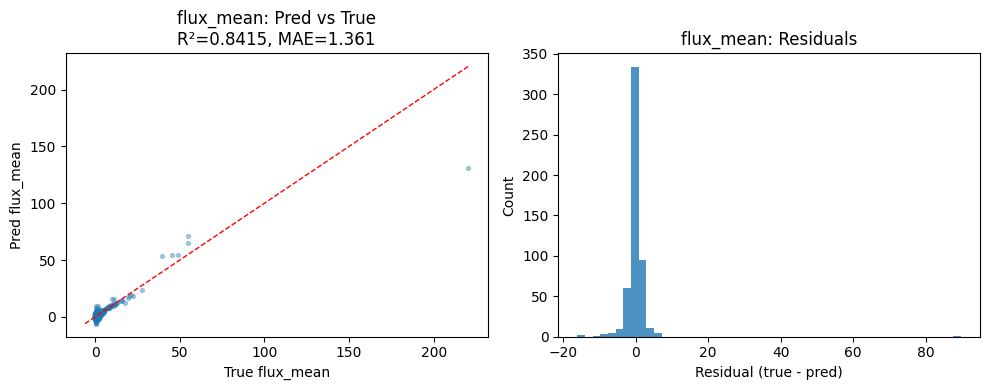

In [61]:
res_fmean = run_regression(cls_emb, flux_mean, label="flux_mean")

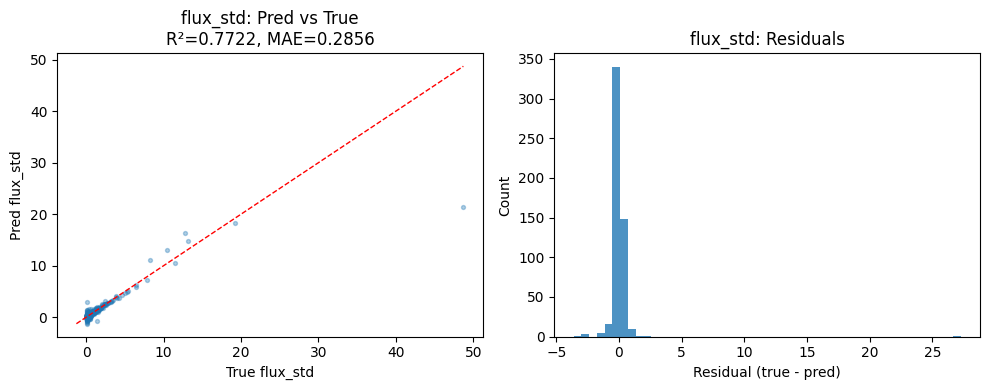

In [62]:
res_fstd = run_regression(cls_emb, flux_std, label="flux_std")

In [63]:
summary_df = pd.DataFrame([res_z, res_phot, res_fmean, res_fstd])
summary_df

,label,r2,mae
0,z_best,0.613930,0.484868
1,log10(phot_f150w_tot_1),0.845350,0.175209
2,flux_mean,0.841534,1.360868
3,flux_std,0.772169,0.285565


## 1b. Regression (Token-Mean Pooling)

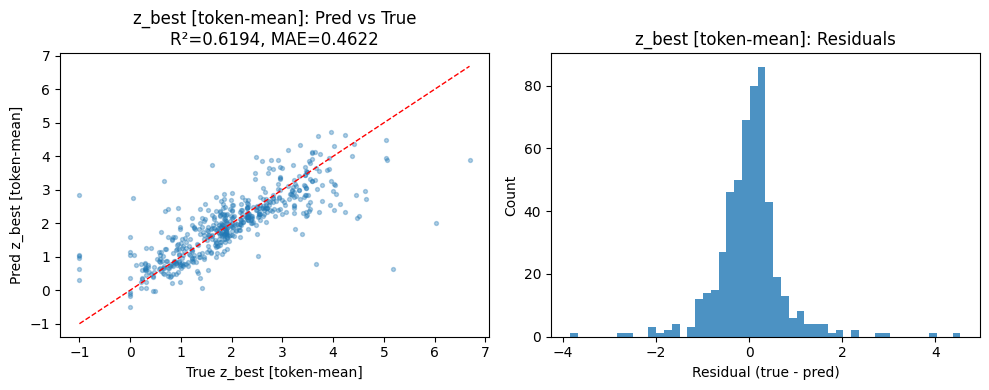

In [64]:
res_z_tok = run_regression(tok_pool_emb, z_best, label="z_best [token-mean]")

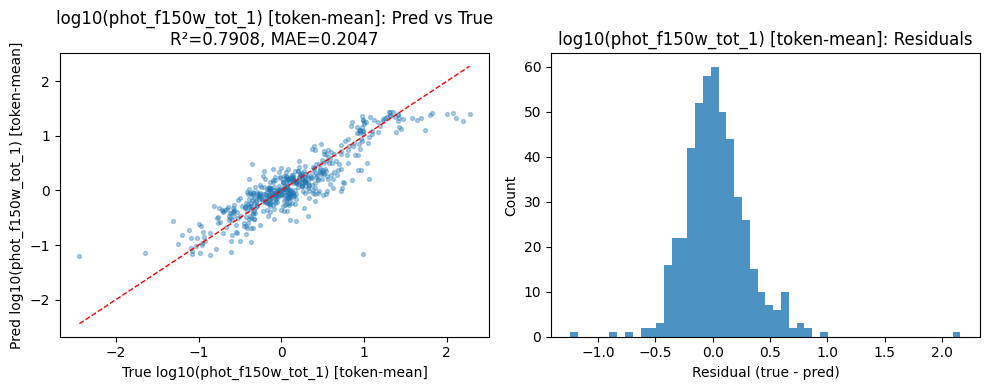

In [65]:
mask_phot_pos = phot > 0
res_phot_tok = run_regression(
    tok_pool_emb[mask_phot_pos],
    np.log10(phot[mask_phot_pos]),
    label="log10(phot_f150w_tot_1) [token-mean]",
)

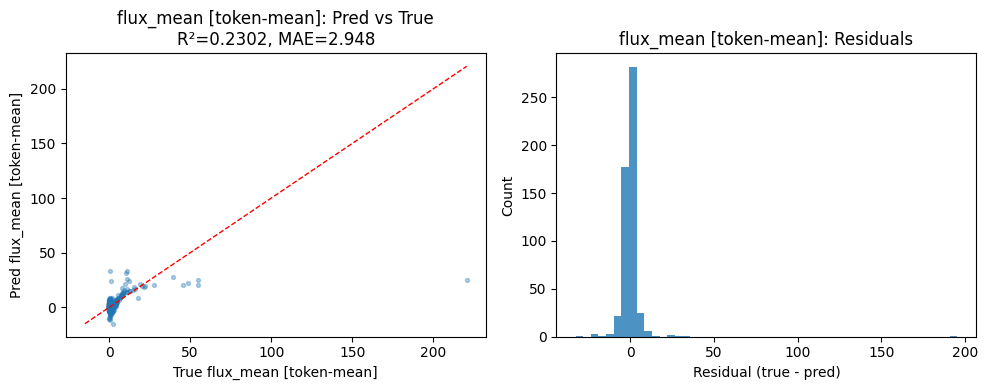

In [66]:
res_fmean_tok = run_regression(tok_pool_emb, flux_mean, label="flux_mean [token-mean]")

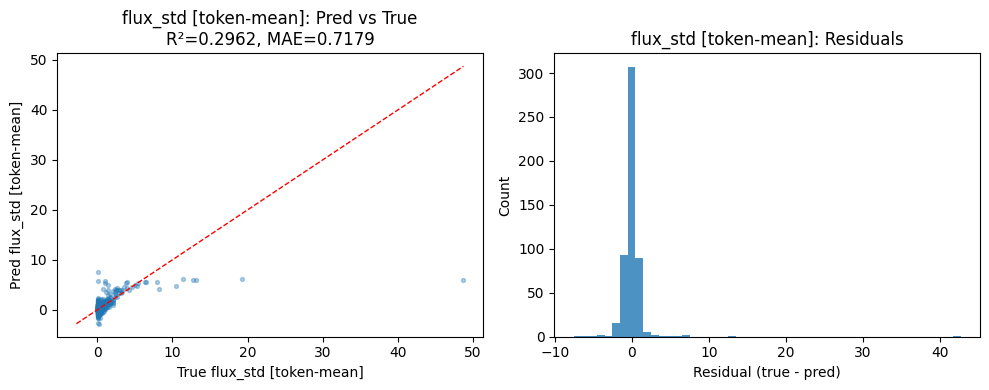

In [67]:
res_fstd_tok = run_regression(tok_pool_emb, flux_std, label="flux_std [token-mean]")

In [68]:
summary_compare = pd.DataFrame([
    {"feature": "CLS", **res_z},
    {"feature": "TokenMean", **res_z_tok},
    {"feature": "CLS", **res_phot},
    {"feature": "TokenMean", **res_phot_tok},
    {"feature": "CLS", **res_fmean},
    {"feature": "TokenMean", **res_fmean_tok},
    {"feature": "CLS", **res_fstd},
    {"feature": "TokenMean", **res_fstd_tok},
])
summary_compare

,feature,label,r2,mae
0,CLS,z_best,0.613930,0.484868
1,TokenMean,z_best [token-mean],0.619398,0.462153
2,CLS,log10(phot_f150w_tot_1),0.845350,0.175209
3,TokenMean,log10(phot_f150w_tot_1) [token-mean],0.790830,0.204690
4,CLS,flux_mean,0.841534,1.360868
5,TokenMean,flux_mean [token-mean],0.230232,2.948417
6,CLS,flux_std,0.772169,0.285565
7,TokenMean,flux_std [token-mean],0.296156,0.717947


## 2. Embedding Visualization

In [69]:
rng = np.random.default_rng(42)
N = len(cls_emb)
idx_viz = rng.choice(N, size=min(N_VIZ, N), replace=False)

X_viz = cls_emb[idx_viz]
z_viz = z_best[idx_viz]
phot_viz = phot[idx_viz]
sn50_viz = sn50[idx_viz]

X_scaled = StandardScaler().fit_transform(X_viz)

emb_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
emb_tsne = TSNE(n_components=2, init="pca", perplexity=30, random_state=42).fit_transform(X_scaled)
emb_umap = None
if HAS_UMAP:
    emb_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled)

print(f"Visualization sample size: {len(X_viz):,}")
print(f"UMAP available: {HAS_UMAP}")


/home/yacheng/ssl_outthere/.venv/lib64/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Visualization sample size: 2,625
UMAP available: True


In [70]:
def plot_embeddings(embeddings_dict, values, value_name, cmap="viridis"):
    panels = list(embeddings_dict.items())
    fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4))
    if len(panels) == 1:
        axes = [axes]

    for ax, (title, emb) in zip(axes, panels):
        sc = ax.scatter(emb[:, 0], emb[:, 1], c=values, s=8, alpha=0.7, cmap=cmap)
        ax.set_title(f"{title} colored by {value_name}")
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")
        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


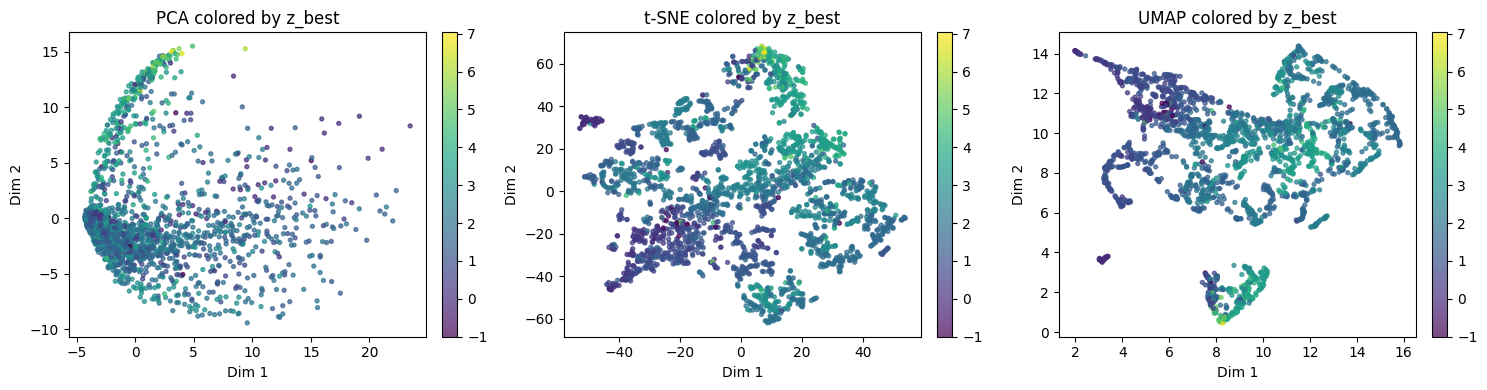

In [71]:
embeddings_all = {
    "PCA": emb_pca,
    "t-SNE": emb_tsne,
}
if emb_umap is not None:
    embeddings_all["UMAP"] = emb_umap

plot_embeddings(embeddings_all, z_viz, "z_best", cmap="viridis")

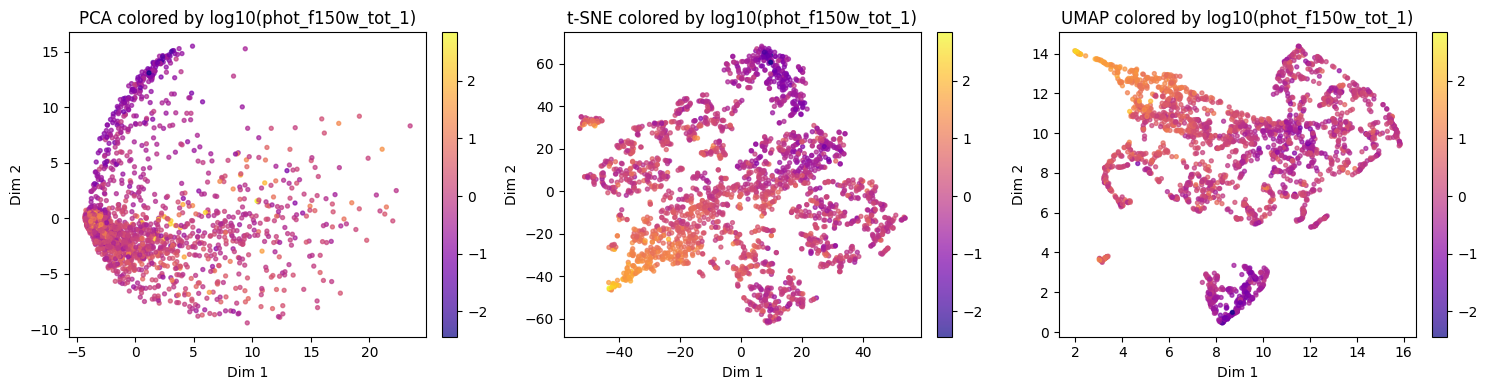

In [72]:
mask_phot_pos_viz = phot_viz > 0
embeddings_phot = {k: v[mask_phot_pos_viz] for k, v in embeddings_all.items()}
plot_embeddings(embeddings_phot, np.log10(phot_viz[mask_phot_pos_viz]), "log10(phot_f150w_tot_1)", cmap="plasma")

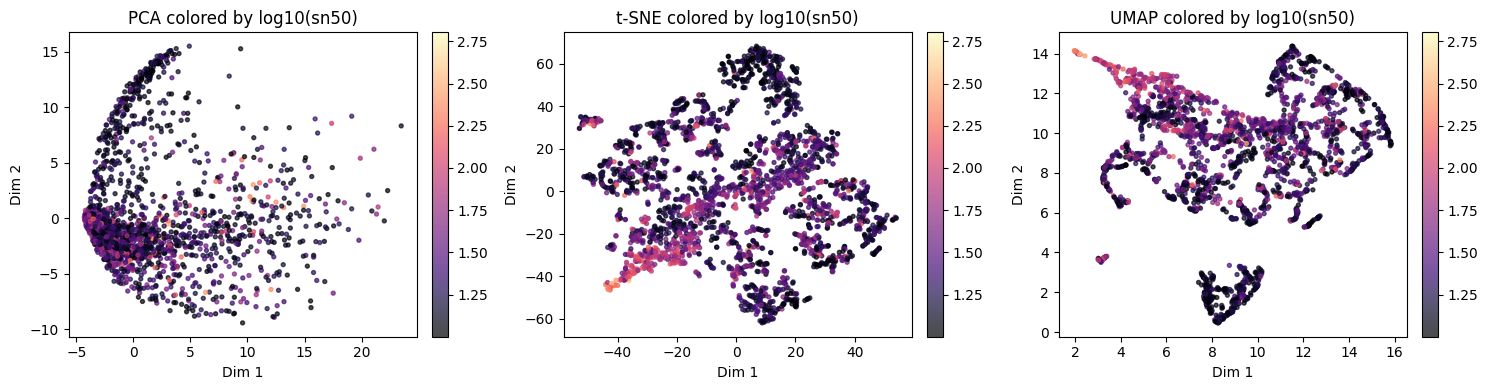

In [73]:
mask_sn50_pos_viz = sn50_viz > 0
embeddings_sn50 = {k: v[mask_sn50_pos_viz] for k, v in embeddings_all.items()}
plot_embeddings(embeddings_sn50, np.log10(sn50_viz[mask_sn50_pos_viz]), "log10(sn50)", cmap="magma")

## 3. Image Encoder (Stub)

In [74]:
IMG_CKPT_PATH = Path(IMG_CKPT)

if IMG_CKPT_PATH.exists():
    print("Image checkpoint found:", IMG_CKPT_PATH)
    print("\nStub pipeline:")
    print("1) Build model with dinov2.eval.setup.build_model_for_eval(cfg, pretrained_weights)")
    print("2) Extract [CLS] image embeddings in dataset.valid_indices order")
    print("3) Reuse regression + visualization pipeline above")
    print("\nExample imports:")
    print("from omegaconf import OmegaConf")
    print("from dinov2.eval.setup import build_model_for_eval")
    print("cfg = OmegaConf.load('encoder_image/astrodino/train/configs/astrodino_jwst_vitb_f150w.yaml')")
    print("img_model = build_model_for_eval(cfg, pretrained_weights=str(IMG_CKPT_PATH))")
else:
    print(f"No local image checkpoint found at: {IMG_CKPT_PATH}")
    print("Image section skipped.")
    print("Hint: if you see size-mismatch errors, use config")
    print("'encoder_image/astrodino/train/configs/astrodino_jwst_vitb_f150w.yaml'")
    print("because it uses embed_dim=768 to match ViT-B checkpoints.")


No local image checkpoint found at: /home/yacheng/ssl_outthere/encoder_image/astrodino/outputs/does_not_exist.ckpt
Image section skipped.
Hint: if you see size-mismatch errors, use config
'encoder_image/astrodino/train/configs/astrodino_jwst_vitb_f150w.yaml'
because it uses embed_dim=768 to match ViT-B checkpoints.
